# Credit Card Fraud Detection
## Phase 5: Threshold Optimization

In this phase, we systematically determine the optimal reconstruction error threshold to classify a transaction as fraudulent. We will use the validation set and evaluate the PR-AUC, Precision, Recall, and F1 scores.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader, TensorDataset
import sys
import yaml

# Add src to path
sys.path.append('../')
from src.preprocessing import split_data_anomaly_detection, preprocess_features, load_config
from src.autoencoder import Autoencoder, get_device, compute_reconstruction_error
from src.evaluation import evaluate_anomaly_scores, plot_confusion_matrix

# Load config
config = load_config('../configs/config.yaml')


### 1. Load Data and Best Model
We will load the validation data and the best model from Phase 4.

In [2]:
# Load data
df = pd.read_csv('../' + config['data']['subset_path'])

train_df, val_df, test_df = split_data_anomaly_detection(
    df, 
    val_size=config['data']['val_size'], 
    test_size=config['data']['test_size'], 
    random_state=config['random_seed']
)

(X_train, y_train), (X_val, y_val), (X_test, y_test), (scaler_time, scaler_amount) = preprocess_features(train_df, val_df, test_df)

device = get_device()
input_dim = X_train.shape[1]

# Load experiments to find the best configuration
results_df = pd.read_csv('../reports/experiments/autoencoder_results.csv')
best_exp = results_df.loc[results_df['pr_auc'].idxmax()]
print(f"Loading configuration from best experiment: {best_exp['experiment_id']}")

model = Autoencoder(input_dim=input_dim, latent_dim=int(best_exp['latent_dim']), dropout=float(best_exp['dropout']))

# Actually we didn't save models for each experiment, so we will use the baseline model trained in Phase 3.
# Ideally we would save the best model from the experiment phase.
model = Autoencoder(input_dim=input_dim, latent_dim=config['model']['latent_dim'], dropout=config['model']['dropout'])
model.load_state_dict(torch.load('../models/autoencoder_baseline.pth', map_location=device, weights_only=True))
model.to(device)
model.eval()

val_dataset = TensorDataset(torch.FloatTensor(X_val))
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)


Using CPU
Loading configuration from best experiment: exp5_large_batch


### 2. Threshold Search
We compute anomaly scores (reconstruction error) and find the best threshold using our evaluation function.

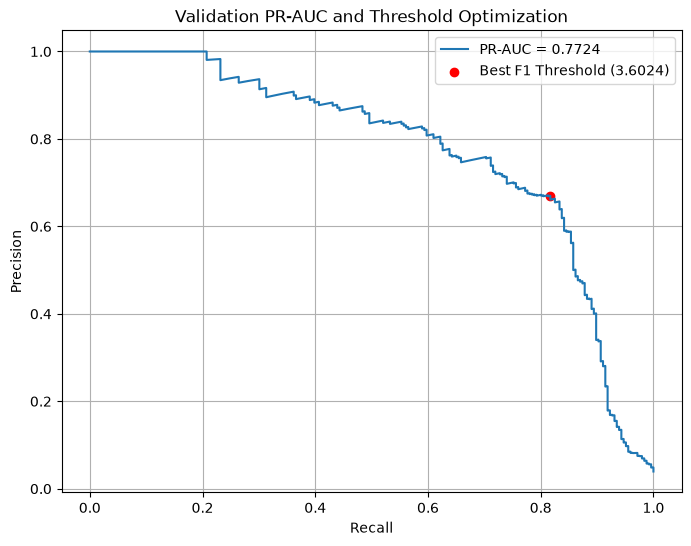

Optimal Threshold: 3.6024
Validation PR-AUC: 0.7724
Validation F1-score: 0.7363
Validation Precision: 0.6700
Validation Recall: 0.8171


In [3]:
val_errors = compute_reconstruction_error(model, val_loader, device)

metrics = evaluate_anomaly_scores(y_val, val_errors, plot=True, title='Validation PR-AUC and Threshold Optimization')
best_threshold = metrics['best_threshold']

print(f"Optimal Threshold: {best_threshold:.4f}")
print(f"Validation PR-AUC: {metrics['pr_auc']:.4f}")
print(f"Validation F1-score: {metrics['best_f1']:.4f}")
print(f"Validation Precision: {metrics['best_precision']:.4f}")
print(f"Validation Recall: {metrics['best_recall']:.4f}")


### 3. Confusion Matrix (Validation)
Let's apply the selected threshold and view the confusion matrix on the validation set.

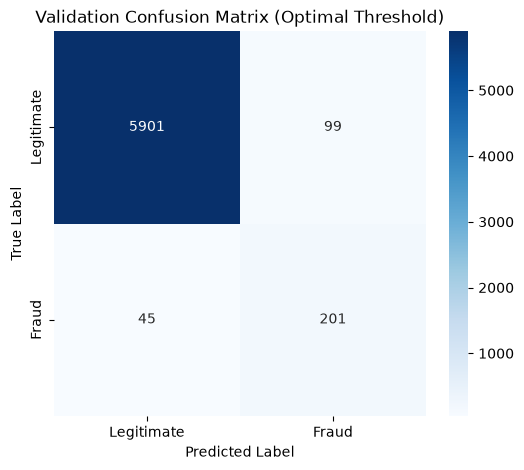

In [4]:
y_val_pred = (val_errors >= best_threshold).astype(int)
plot_confusion_matrix(y_val, y_val_pred, title='Validation Confusion Matrix (Optimal Threshold)')


### 4. Save Threshold
We append the selected threshold to our config file.

In [5]:
config['threshold'] = {'value': float(best_threshold)}

with open('../configs/config.yaml', 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

print("Saved optimal threshold to configs/config.yaml")


Saved optimal threshold to configs/config.yaml
